
# 🚀 HDFS Log Pipeline (Optimized & LSTM Ready)

This notebook is **memory-safe + optimized** and includes:

## ✅ Features
- HuggingFace dataset loading
- Controlled sequence generation (NO memory crash)
- Smart anomaly-aware sampling
- Class imbalance handling
- LSTM-ready dataset
- Versioned saving

---

## 🔥 Key Improvements

Instead of generating ALL sequences (which causes MemoryError), we:

### 1. Use Step Size
Skip overlapping redundant sequences

### 2. Limit Sequences per Block
Prevent explosion from long blocks

### 3. Smart Trick (IMPORTANT)
Generate MORE sequences from anomaly blocks (but safely)

---



In [5]:

# =========================
# INSTALL & IMPORTS
# =========================


import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import resample


In [6]:

# =========================
# LOAD DATASET
# =========================

dataset = load_dataset("honicky/hdfs-logs-encoded-blocks")
df = pd.DataFrame(dataset['train'])

print("Dataset loaded:", df.shape)
df.head()


Dataset loaded: (460048, 5)


,event_encoded,tokenized_block,block_id,label,__index_level_0__
0,<|sep|>0 /10.251.67.211:54457 /10.251.67.211:5...,"[50277, 17, 1227, 740, 15, 21451, 15, 2251, 15...",blk_-4040947678439826686,Normal,257494
1,<|sep|>6 <|sep|>0 /10.251.106.37:36707 /10.251...,"[50277, 23, 209, 50277, 17, 1227, 740, 15, 214...",blk_1870752360007129176,Normal,49365
2,<|sep|>6 <|sep|>0 /10.251.121.224:40809 /10.25...,"[50277, 23, 209, 50277, 17, 1227, 740, 15, 214...",blk_-1999301527305082358,Normal,7319
3,<|sep|>0 /10.251.123.20:56258 /10.251.123.20:5...,"[50277, 17, 1227, 740, 15, 21451, 15, 10683, 1...",blk_-2322520798745751605,Normal,295080
4,<|sep|>6 <|sep|>0 /10.251.107.242:55242 /10.25...,"[50277, 23, 209, 50277, 17, 1227, 740, 15, 214...",blk_-4090429635427697097,Normal,64733


In [7]:

# =========================
# PARAMETERS (BEST SETUP)
# =========================

history_len = 10
future_len = 20

# Memory-safe controls
normal_step = 5
anomaly_step = 2

normal_max = 50
anomaly_max = 80


In [8]:

# =========================
# OPTIMIZED SEQUENCE GENERATION
# =========================

X = []
y = []

for _, row in df.iterrows():

    seq = row["tokenized_block"]
    label = row["label"]

    if len(seq) < history_len + future_len:
        continue

    # SMART TRICK
    if label == "Anomaly":
        step_size = anomaly_step
        max_per_block = anomaly_max
    else:
        step_size = normal_step
        max_per_block = normal_max

    count = 0

    for i in range(history_len, len(seq) - future_len, step_size):

        if count >= max_per_block:
            break

        X.append(seq[i-history_len:i])
        y.append(1 if label == "Anomaly" else 0)

        count += 1

X = np.array(X)
y = np.array(y)

print("Final dataset shape:", X.shape)


Final dataset shape: (18223715, 10)


In [9]:

# =========================
# CLASS IMBALANCE CHECK
# =========================

unique, counts = np.unique(y, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Class {u}: {c} ({c/len(y):.4f})")


Class 0: 17515221 (0.9611)
Class 1: 708494 (0.0389)


In [17]:

# =========================
# OPTIONAL UNDERSAMPLING
# =========================

X_majority = X[y == 0]
X_minority = X[y == 1]

y_majority = y[y == 0]
y_minority = y[y == 1]

target_majority = len(y_minority) * 3

if len(y_majority) > target_majority:
    X_majority_down, y_majority_down = resample(
        X_majority, y_majority,
        replace=False,
        n_samples=target_majority,
        random_state=42
    )

    X = np.vstack((X_majority_down, X_minority))
    y = np.hstack((y_majority_down, y_minority))

print("Balanced dataset:", X.shape)


Balanced dataset: (2833976, 10)


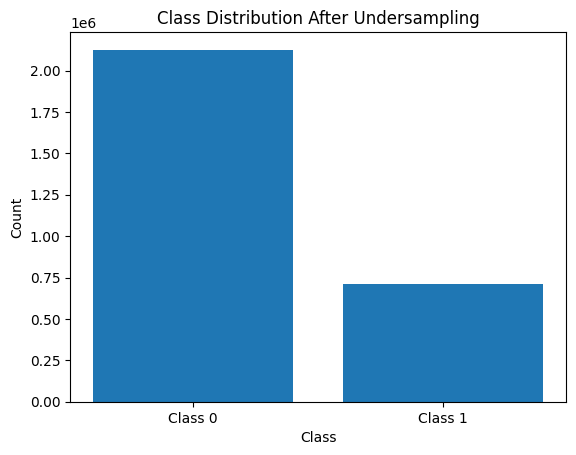

In [18]:

import numpy as np
import matplotlib.pyplot as plt

classes, counts = np.unique(y, return_counts=True)

plt.figure()
plt.bar(classes, counts)

# 🔥 FIX: force correct x-axis labels
plt.xticks(classes, [f"Class {int(c)}" for c in classes])

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution After Undersampling")

plt.show()

In [19]:
# =========================
# CLASS WEIGHTS (AFTER UNDERSAMPLING)
# =========================

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y)  # y AFTER undersampling

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y
)

class_weight_dict = dict(zip(classes, class_weights))

print("Class weights (after undersampling):", class_weight_dict)

Class weights (after undersampling): {np.int64(0): np.float64(0.6666666666666666), np.int64(1): np.float64(2.0)}


In [20]:

# =========================
# LSTM READY
# =========================

X_tensor = torch.tensor(X, dtype=torch.long)
y_tensor = torch.tensor(y, dtype=torch.long)

print("Tensor shape:", X_tensor.shape)


Tensor shape: torch.Size([2833976, 10])


In [21]:

# =========================
# SAVE DATASET
# =========================

np.save(f"X_seq_h{history_len}_f{future_len}.npy", X)
np.save(f"y_seq_h{history_len}_f{future_len}.npy", y)

print("Saved successfully!")


Saved successfully!
